# Kelly first tests and models

In [1]:
#Faire tous les test nps 
#Faire tests courtiers
#Test sur menace de résiliation

#--> privilégier régressions; régressions linéaires

#tester la méthode d'encoding développée par Dominique
#  sur les variables à fortes modalités (nbr enfant, type produit!!!) et voir
#si améliore perf de prédictiion (comparer a one hot encoding/mean encoding (tjrs avec la 
#target résiliation sur échantillon de test) )

In [2]:
import os
os.chdir("/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2") 

In [3]:
#Librairies import
import pandas as pd
from merge_and_agregation import *
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
from utils.Visualisation import plot_hist_top_k
import visualisation

import importlib

In [4]:
importlib.reload(visualisation)

<module 'visualisation' from '/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2/visualisation.py'>

In [5]:
#Loading of files
df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_reclamations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_consommations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")

/tmp/ipykernel_83263/1497957394.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


In [6]:
#Agregate and merge
create_clean_aggregated_dataset(df_consommations=df_consommations, df_impayes=df_impayes, df_reclamations=df_reclamations, df_portefeuille=df_portefeuille, df_interactions=df_interactions).to_csv("df_agregate.csv", index=False)

/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2/merge_and_agregation.py:251: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("client_code").apply(build_info_dict).reset_index(drop=True)
/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2/merge_and_agregation.py:376: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interaction_historique_mail = df_mail.groupby("client_code").apply(


KeyboardInterrupt: 

In [7]:
df=pd.read_csv("df_agregate.csv")

/tmp/ipykernel_83263/4130466241.py:1: DtypeWarning: Columns (31,33,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("df_agregate.csv")


In [ ]:
df

,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,interaction_service_cotisations_recouvrements,interaction_service_prestations_sante,interaction_service_suivi_du_contrat,interaction_autres_services,interaction_canal_telephone_nb,interaction_nb_transferts_reclamation,interaction_nb_transferts_gestion,interaction_nb_transferts_commercial,interaction_nb_transferts_externalises,interaction_historique_mail
0,21736,97,F,SS,69100,69,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22037,95,F,SS,26230,26,NaN,0.0,0.0,femme ss enfant,...,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,"{'2023-01-24': ""xxpj0 xxobj Adhérent 3148 Mme..."
2,22331,88,M,TNS,69760,69,NaN,1.0,0.0,couple ss enfant,...,0.0,10.0,0.0,0.0,10.0,0.0,5.0,0.0,7.0,{}
3,22604,95,F,TNS,69003,69,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22702,90,M,TNS,69100,69,NaN,1.0,0.0,couple ss enfant,...,0.0,8.0,0.0,0.0,8.0,0.0,4.0,0.0,8.0,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132571,16204966,36,M,SS,74140,74,NaN,0.0,0.0,homme ss enfant,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,"{'2023-11-28': ""xxpj0 AttestationDroits xxobj ..."
132572,16205008,63,M,SS,17443,17,NaN,0.0,0.0,homme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132573,16205281,25,F,SS,74200,74,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132574,16206464,22,F,SS,97215,97,NaN,0.0,0.0,femme ss enfant,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Analyse de la variable target

In [ ]:
print((df["target_resiliation_6mois"]==1).sum()/df.shape[0]*100)
print((df["target_resiliation_6mois"]==1).sum())

14450 clients d'Alptis ont résilié entre 1er décembre 2023 
et le 31 mai 2024, soit 10,89 % des clients de l'année.

# Analyse du DataFrame merged

In [8]:
len(df.columns) #135 colonnes

135

## Analyse de la target en lien avec les variables de réclamations

In [9]:
[column for column in df.columns if column.startswith("recla")]

['recla_nombre',
 'recla_motif_Couverture et fonctionnement de la garantie',
 'recla_motif_Délai de traitement',
 'recla_motif_Montant des remboursements / Indemnités',
 'recla_motif_Frais',
 'recla_motif_Demandes de compléments / pièces',
 'recla_motif_Autre',
 'recla_canal_entrant_principale',
 'recla_canal_entrant_secondaire',
 'recla_sensible_resiliation',
 'recla_sensible_tiers',
 'recla_sensible_courtier',
 'recla_sensible_autre',
 'recla_initiateur_client',
 'recla_non_cloturee',
 'recla_date_reception',
 'recla_delais_court',
 'recla_delais_moyen',
 'recla_delais_long']

In [ ]:
df_reclamations.shape #11045 clients ayant faits des réclamations

(11045, 12)

Avec réclamation : 19.15325307723522 %
Sans réclamation : 10.411956895105567 %


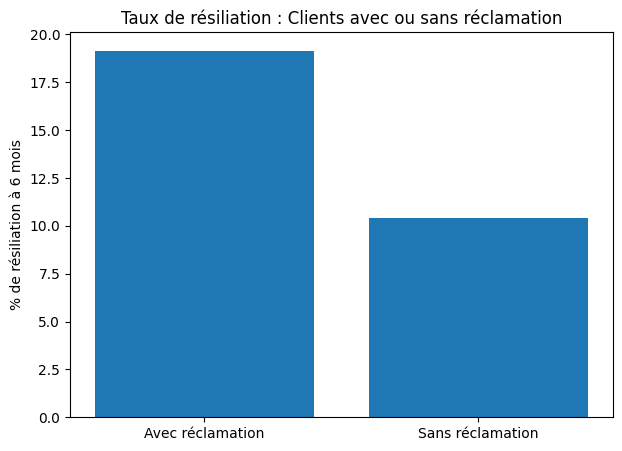

In [ ]:
import matplotlib.pyplot as plt

# % résiliation chez les clients avec réclamation
pct_resiliation_recla = (
    df[df["recla_nombre"] > 0]["target_resiliation_6mois"].mean() * 100
)

# % résiliation chez les clients sans réclamation
pct_resiliation_sans_recla = (
    df[df["recla_nombre"] == 0]["target_resiliation_6mois"].mean() * 100
)

print("Avec réclamation :", pct_resiliation_recla, "%")
print("Sans réclamation :", pct_resiliation_sans_recla, "%")

# ---------- Plot ----------
labels = ["Avec réclamation", "Sans réclamation"]
values = [pct_resiliation_recla, pct_resiliation_sans_recla]

plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.ylabel("% de résiliation à 6 mois")
plt.title("Taux de résiliation : Clients avec ou sans réclamation")
plt.show()


Avec menace de résiliation : 27.500000000000004 %
Sans menace de résiliation : 10.89439850304823 %


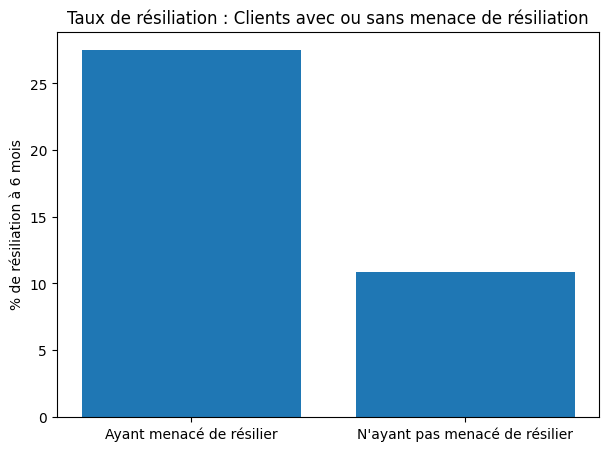

In [ ]:
#Analyse menace résiliation vs résiliation réelle 

# % résiliation chez les clients ayant faits au moins une menace de résiliation
pct_resiliation_recla = (
    df[df["recla_sensible_resiliation"] > 0]["target_resiliation_6mois"].mean() * 100
)

# % résiliation chez les clients sans menace de résiliation
pct_resiliation_sans_recla = (
    df[df["recla_sensible_resiliation"] == 0]["target_resiliation_6mois"].mean() * 100
)

print("Avec menace de résiliation :", pct_resiliation_recla, "%")
print("Sans menace de résiliation :", pct_resiliation_sans_recla, "%")

# ---------- Plot ----------
labels = ["Ayant menacé de résilier", "N'ayant pas menacé de résilier"]
values = [pct_resiliation_recla, pct_resiliation_sans_recla]

plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.ylabel("% de résiliation à 6 mois")
plt.title("Taux de résiliation : Clients avec ou sans menace de résiliation")
plt.show()


<Axes: >

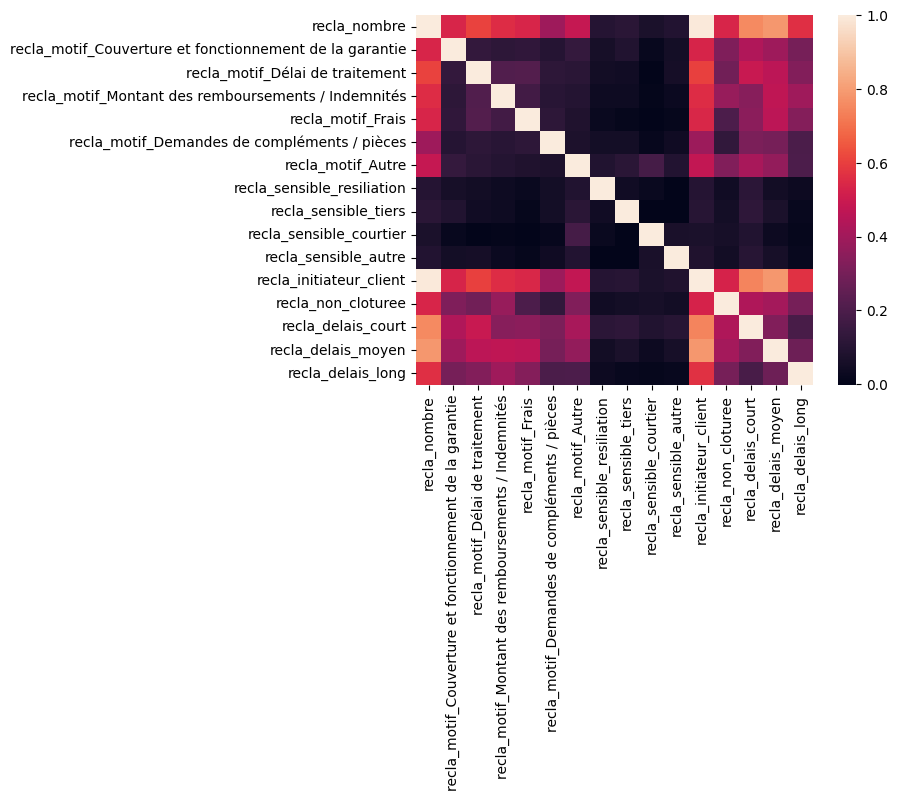

In [ ]:
#Matrice de corrélation sur le fichier des réclamations
corr=df[[column for column in df.columns if column.startswith("recla") and column not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"]]].dropna().corr()
sns.heatmap(corr)

Data Preparation

In [ ]:
#Data Preparation 

#Creation of a dummy variable on secondary canal
df["recla_canal_secondaire"]=df["recla_canal_entrant_secondaire"].notna().astype(int)

#Definition of explanatory and explicative variables
X= df[["recla_sensible_resiliation","recla_nombre", "recla_delais_long", "recla_canal_secondaire"]]
y= df["target_resiliation_6mois"]

#Commentary: no need to standardize the variables since its only binary variables or compting variables between 0-10

#Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

Accuracy: 0.8896515311510031
F1 score: 0.0006830601092896175
Recall score: 0.0003429355281207133
Precision score: 0.0003429355281207133


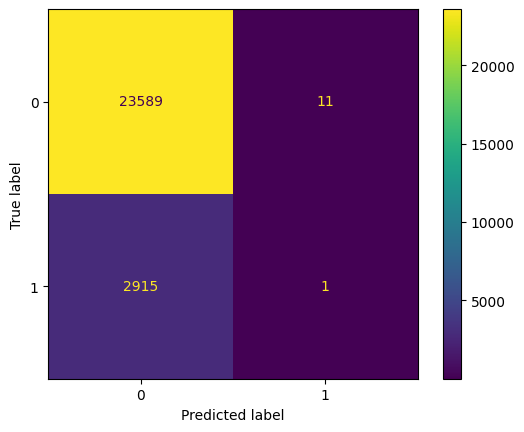

In [121]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
lr =LogisticRegression()

lr.fit(X_train, Y_train)

#Accuracy
print(f"Accuracy: {lr.score(X_test, Y_test)}")

#Confusion Matrix
cm= confusion_matrix(Y_test, lr.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

#F1, Recall, Precision
print(f"F1 score: {f1_score(Y_test, lr.predict(X_test))}")
print(f"Recall score: {recall_score(Y_test, lr.predict(X_test))}")
print(f"Precision score: {recall_score(Y_test, lr.predict(X_test))}")

In [136]:
print(f"Pourcentage de clients ayant résiliés dans le dataset train: {(Y_train.sum()/len(Y_train)*100).round(0)}%")

Pourcentage de clients ayant résiliés dans le dataset train: 11.0%


Accuracy: 0.8568788655905868
F1 score: 0.13808766749943222
Recall score: 0.10425240054869685
Precision score: 0.20443846671149965


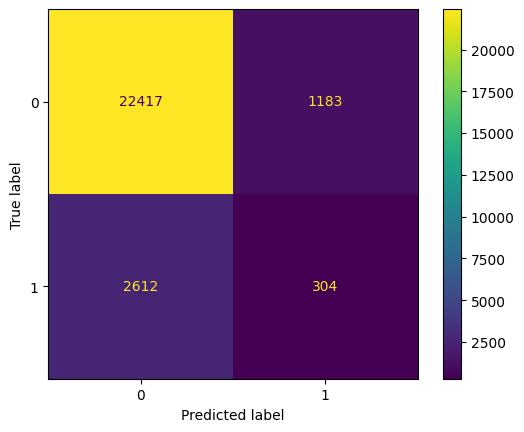

In [128]:
#Logistique regression en équilibrant la répartition du label avec "class_weight = balanced"
#permet de donner un poids plus fort aux erreur de misclassification sur la classe 1

lr =LogisticRegression(class_weight='balanced') #Equilibrage du label

lr.fit(X_train, Y_train)
print(f"Accuracy: {lr.score(X_test, Y_test)}")

#Confusion Matrix
cm= confusion_matrix(Y_test, lr.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

#Recall, Precision, F1
print(f"F1 score: {f1_score(Y_test, lr.predict(X_test))}")
print(f"Recall score: {recall_score(Y_test, lr.predict(X_test))}")
print(f"Precision score: {precision_score(Y_test, lr.predict(X_test))}")

**Conclusion de la régression logistique**

Un bon score d'accuracy, mais en réalité une mauvaise classification si l'on regarde le F1 et la matrice de confusion: seul 1 client ayant résilié est bien classifié! En fait, les données sont déséquilibrées entre la classe 0 (pas de résiliation) et 1 (résiliation): il y a très peu de clients qui ont résilié (11%), donc le modèle prédit toujours 0 ce qui donne une bonne accuracy, mais mauvais en pratique. 

Amélioration mais problème persiste lorsqu'on donne un poids plus fort aux erreurs sur la classe minoritaire 0 avec "class_weight= balanced" (même si 304 clients ayant résilié correctement classifiés au lieu de 1)

**Commentaire sur la mesure de la classification**
- L'accuracy est une mauvaise mesure du modèle dans notre contexte de données déséquilibrées. On préfère mesurer le Recall/Precision/F1. 
- Recall= TP/(TP+FN) -> Nbre de fois où prédit 1 correctement, parmi toutes les données associées à 1
- Precision = TP/(TP+FP) -> Nbre de fois où prédit 1 correctement, parmi toutes les fois où on a prédit 1
- F1 = Recall*Precision/(Precision+Recall) -> Mesure équilibrée entre le Recall et la Précision

Le Recall plus important dans notre problème car plus important: ne pas  misclassifier un client ayant résilié.

Testons des modèles d'ensemble, plus adaptés aux données déséquilibrées: RandomForest et XGBoost

Random Forest

In [ ]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier

# Train and Test
rf= RandomForestClassifier(class_weight= "balanced")
rf.fit(X_train, Y_train)

#Scores
print(f"Recall score: {recall_score(Y_test, rf.predict(X_test))}")
print(f"Precision score: {precision_score(Y_test, rf.predict(X_test))}")

Recall score: 0.10253772290809328
Precision score: 0.2069204152249135


XGBoost

In [150]:

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

#Label encoding to conduct XGBoost
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.fit_transform(Y_test)


xgboost= XGBClassifier(scale_pos_weight = (Y_train.sum() / (len(Y_train)-Y_train.sum()))) #balance les données pour donner + de poids à 1
xgboost.fit(X_train, Y_train_encoded)

#Precision, Recall
print(f"Recall score: {recall_score(Y_test, xgboost.predict(X_test))}") #pire que randomforest et logistic regression
print(f"Precision score: {precision_score(Y_test, xgboost.predict(X_test))}")

Recall score: 0.0
Precision score: 0.0


/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Pas d'amélioration, voire une détérioration du Recall avec RandomForest et XGBoost.

 Tentons de rééquilibrer totalement les données avec **SMOTE** (technique qui permet de générer des données synthétiques portant le label 0) pour atteindre un équilibre 50% entre résiliation et non résiliation dans le dataset test et retestons tous les modèles;

In [156]:
#Equilibre du dataset train avec SMOTE (resampling)
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_res, Y_res = sm.fit_resample(X_train, Y_train)

#Entrainement et test des modèles avec mesure de score 

#Logistic Regression
lr =LogisticRegression()
lr.fit(X_res, Y_res)
print(f"Recall score Logistic Regression: {recall_score(Y_test, lr.predict(X_test))}")
print(f"Precision score Logistic Regression: {precision_score(Y_test, lr.predict(X_test))}")

#RandomForest
rf= RandomForestClassifier()
rf.fit(X_res, Y_res)
print(f"Recall score Random Forest: {recall_score(Y_test, rf.predict(X_test))}")
print(f"Precision score Random Forest:  {precision_score(Y_test, rf.predict(X_test))}")
from sklearn.ensemble import RandomForestClassifier


#XGBoost
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.fit_transform(Y_test)
xgboost= XGBClassifier() 
xgboost.fit(X_train, Y_train_encoded)
print(f"Recall score of XGBoost: {recall_score(Y_test, xgboost.predict(X_test))}") #pire que randomforest et logistic regression
print(f"Precision score of XGBoost: {precision_score(Y_test, xgboost.predict(X_test))}")

Recall score Logistic Regression: 0.10425240054869685
Precision score Logistic Regression: 0.20443846671149965
Recall score Random Forest: 0.10253772290809328
Precision score Random Forest:  0.2072072072072072
Recall score of XGBoost: 0.0003429355281207133
Precision score of XGBoost: 0.125


Le SMOTE améliore légèrement les scores du XGBoost mais globalement mauvais score pour tous les modèles. Le meilleur modèle en terme de Recall est la Régression Logistique.

Analysons les signaux portés par les différentes variables explicatives pour voir si le problème du modèle ne vient pas de là.

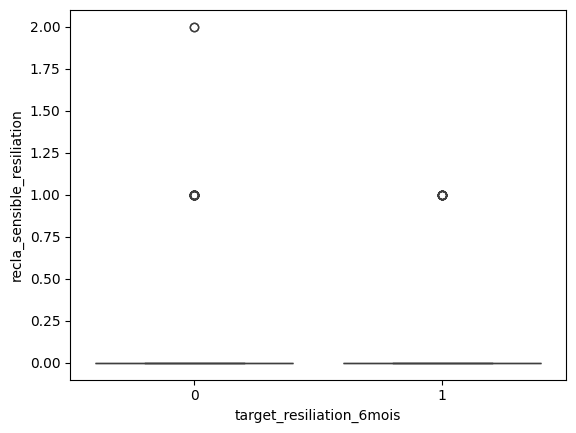

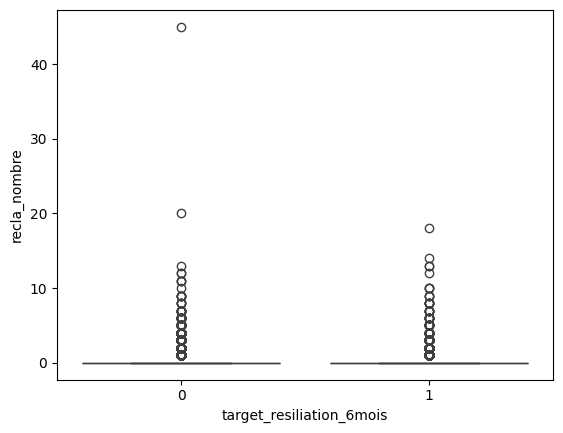

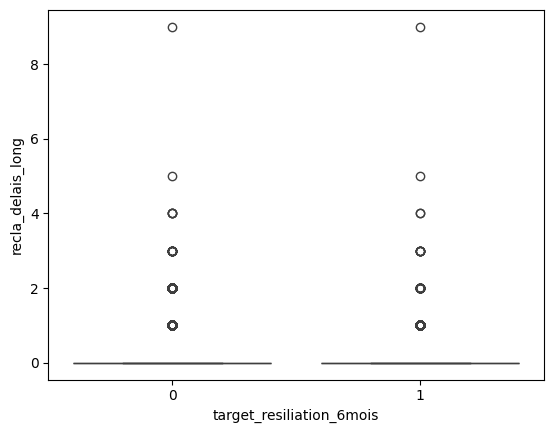

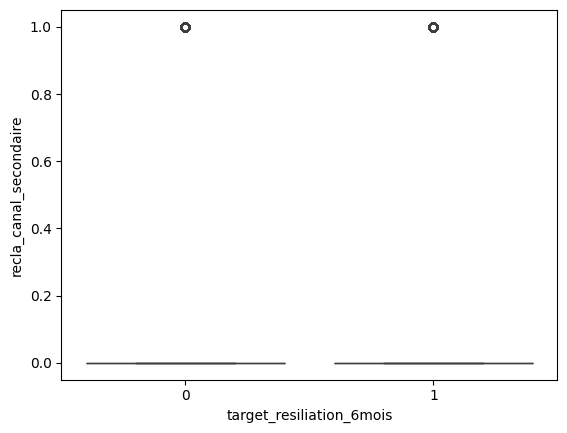

In [160]:
#Analyse des signaux portés par chaque variable explicative par boxplot (comparaison boxplot 1 et 0)

for col in X.columns:
    sns.boxplot(x=Y, y=X[col])
    plt.show()


Les variables explicatives ont des distributions presque identitiques pour y=1 et y=0. Ainsi, les variables explicatives sélectionnées ne semblent pas porter de signal assez fort pour différencier une résiliation d'une non résiliation, d'où les scores très faibles de tous les modèles testés.

## Détection de signaux sur variables explicatives

 Détection de signaux sur les variables liées aux réclamations

<Axes: >

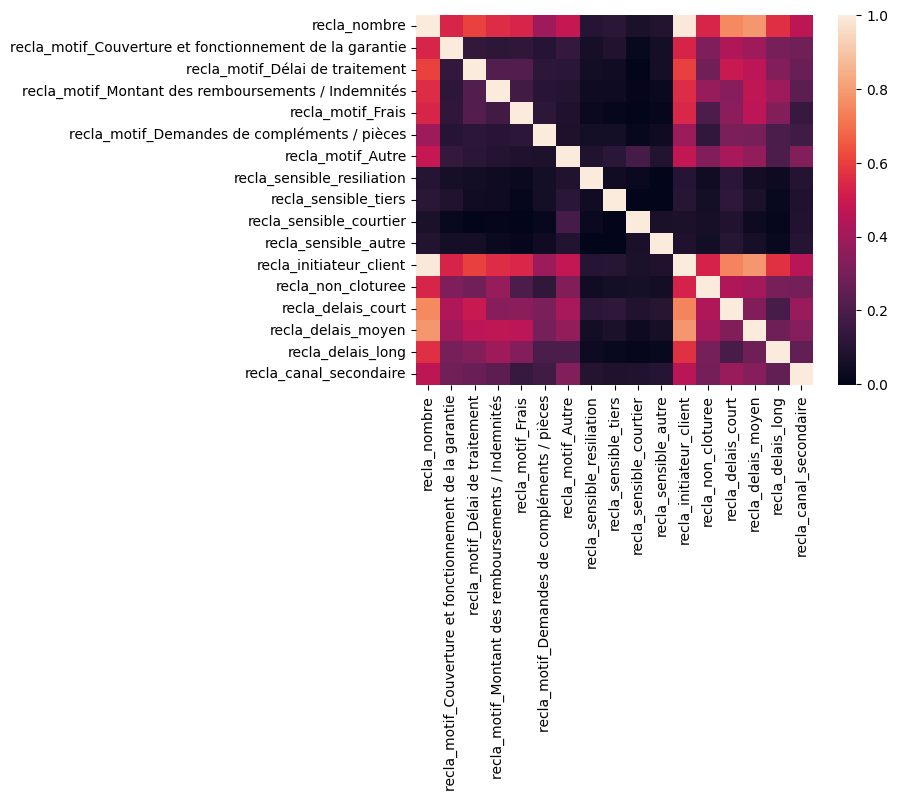

In [174]:
#Matrice de corrélation sur les variables des réclamations pour détecter les variables corrélées
corr=df[[column for column in df.columns if column.startswith("recla") and column not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"]]].dropna().corr()
sns.heatmap(corr)

In [196]:

#Feature importance sur toutes les colonnes de reclamation non catégorielles
rf = RandomForestClassifier()
X= df[[c for c in df.columns if c.startswith("recla") if c not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"] ]]
#X= df[[c for c in df.columns if c.startswith("courtier") if c not in ["courtier_reseau_courtage","courtier_segmentation_interne","courtier_type_commission"]]]
rf.fit(X, Y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

recla_initiateur_client                                    0.110266
recla_nombre                                               0.102514
recla_delais_court                                         0.098274
recla_delais_moyen                                         0.094031
recla_non_cloturee                                         0.077618
recla_delais_long                                          0.068599
recla_motif_Couverture et fonctionnement de la garantie    0.067994
recla_motif_Délai de traitement                            0.067380
recla_motif_Montant des remboursements / Indemnités        0.061472
recla_canal_secondaire                                     0.057362
recla_motif_Frais                                          0.054218
recla_motif_Autre                                          0.052401
recla_motif_Demandes de compléments / pièces               0.049133
recla_sensible_tiers                                       0.015294
recla_sensible_courtier                         

In [198]:
#Test SHAP


# Split into train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Train a machine learning model
clf.fit(X_train, y_train)

# Make prediction on the testing data
y_pred = clf.predict(X_test)

# Classification Report
print(classification_report(y_pred, y_test))

NameError: name 'clf' is not defined

## Analyse de la target en lien avec le courtier

In [163]:
df[[c for c in df.columns if c.startswith("courtier") ]]
#courtier_code_partenaire/apporteur (code apporteur + précis)
#courtier_anciennete_annees

,courtier_code_partenaire,courtier_anciennete_annees,courtier_code_apporteur,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2
0,87256,23.0,141184,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51
1,87256,15.0,141667,140183.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21
2,87256,23.0,141184,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51
3,87256,15.0,141667,140484.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21
4,87256,23.0,141184,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51
...,...,...,...,...,...,...,...,...,...,...,...,...
132571,115508,16.0,168001,NaN,E_COURTIER,CMA,precompte,0,3400,1908,2561,2141
132572,87256,10.0,189001,NaN,COURTIER CLASSIQUE,Alptis,NaN,0,688,669,620,767
132573,469141,2.0,514158,NaN,COURTIER CLASSIQUE,VIP,lineaire,0,11,0,6,1
132574,332249,10.0,458984,NaN,COURTIER CLASSIQUE,Miltis,lineaire,0,26,20,41,27


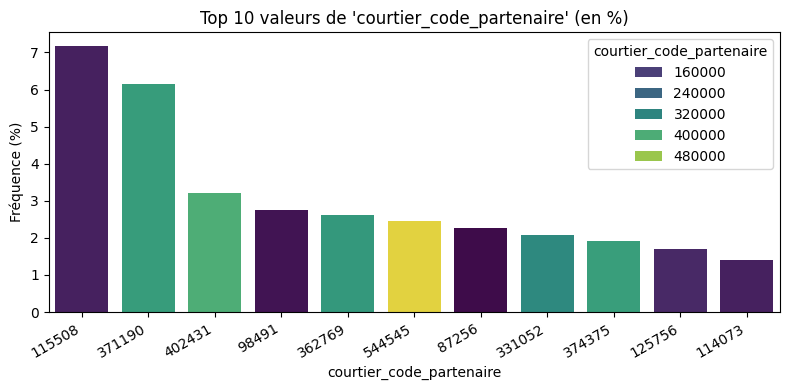

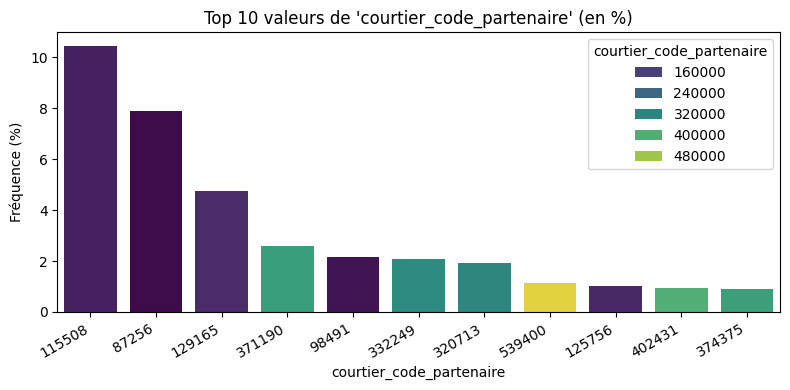

In [18]:
#Courtiers ayant le nombres de clients ayant résilié le plus élévé
plot_hist_top_k(df[df["target_resiliation_6mois"]==1], ["courtier_code_partenaire"], k=10)

#Courtiers les plus présents dans le portefeuille d'Alptis (en terme de nombre de clients associés)
plot_hist_top_k(df, ["courtier_code_partenaire"], 10)

/tmp/ipykernel_73646/255522686.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


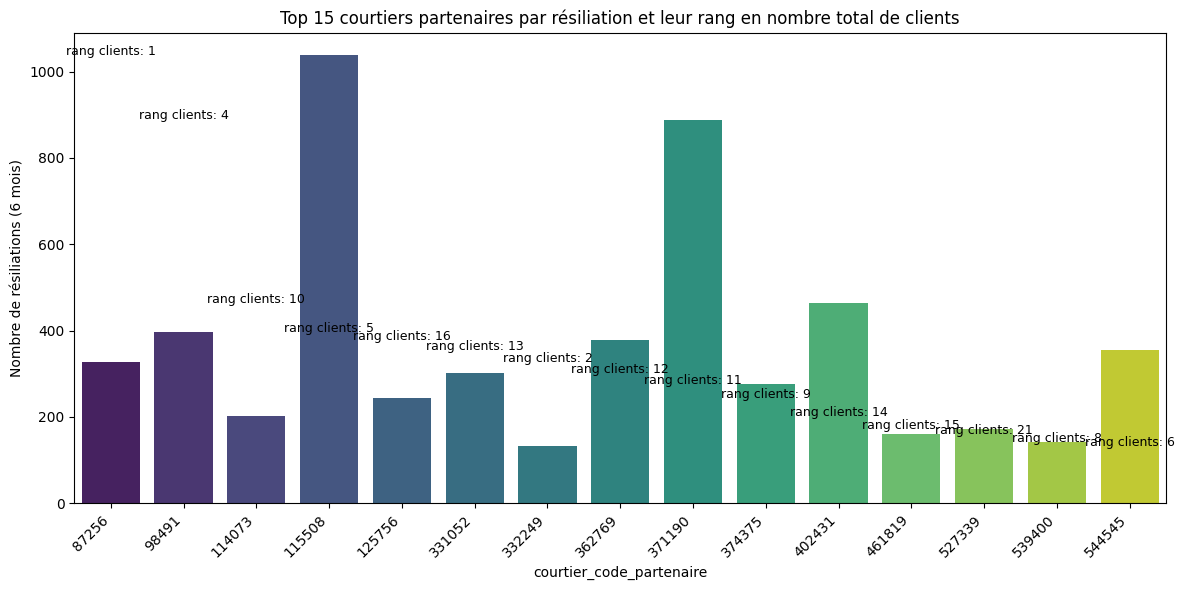

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = ton dataframe avec 'courtier_code_partenaire' et 'target_resiliation_6mois'

# Nombre de résiliations par code partenaire
resil_counts = df.groupby("courtier_code_partenaire")["target_resiliation_6mois"].sum()

# Top 20 codes partenaires par résiliation
top15_resil = resil_counts.sort_values(ascending=False).head(15)
top15_codes = top15_resil.index.tolist()

# 3Nombre total de clients par code partenaire
total_clients = df.groupby("courtier_code_partenaire")["target_resiliation_6mois"].count()

#  Rang des codes top20 selon nombre total de clients
total_clients_rank = total_clients.rank(method="min", ascending=False)
top15_rank = total_clients_rank[top15_codes]

#  Préparer DataFrame pour plot
plot_df = pd.DataFrame({
    "courtier_code_partenaire": top15_codes,
    "nb_resil": top15_resil.values,
    "total_clients": total_clients[top15_codes].values,
    "rang_total_clients": top15_rank.values
})

plot_df = plot_df.sort_values("nb_resil", ascending=False)

# 6️⃣ Visualisation
plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_df,
    x="courtier_code_partenaire",
    y="nb_resil",
    palette="viridis", 
    #order= plot_df["nb_resil"]
)

# Ajouter le rang total clients au-dessus des barres
for i, row in plot_df.iterrows():
    plt.text(
        i, row.nb_resil + 0.5,
        f"rang clients: {int(row.rang_total_clients)}",
        ha="center", fontsize=9
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre de résiliations (6 mois)")
plt.title("Top 15 courtiers partenaires par résiliation et leur rang en nombre total de clients")
plt.tight_layout()
plt.show()

In [20]:
df["courtier_code_partenaire"].nunique()

4862

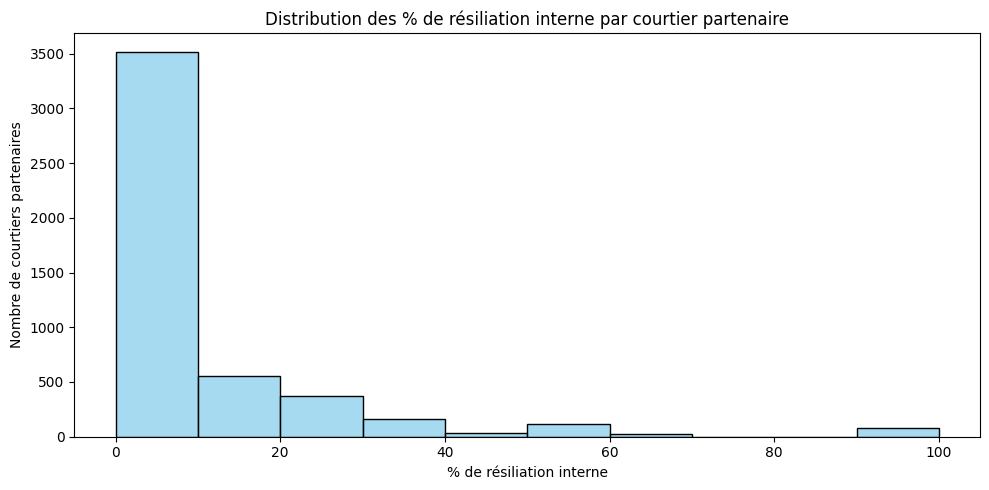

In [21]:
#Création d'un dictionnaire qui associé à un code courtier partenaire son % de résiliation

#Dictionnaire associant à un code partenaire courtier son nombre de client en 2023
dict_client_courtier= df["courtier_code_partenaire"].value_counts().to_dict()

#Dictionnaire associant à un code partenaire courtier son nombre de résiliation en 2023
dict_resiliation_courtier=df.groupby("courtier_code_partenaire").agg({"target_resiliation_6mois": "sum"}).to_dict()["target_resiliation_6mois"]

#Calcul du % de résiliation interne à chaque courtier
dict_pourc_resiliation_courtier= dict()
for courtier in dict_client_courtier.keys():
    dict_pourc_resiliation_courtier[courtier]= dict_resiliation_courtier[courtier]/dict_client_courtier[courtier]*100

df_resiliation = pd.DataFrame(list(dict_pourc_resiliation_courtier.items()), columns=["courtier_code_partenaire", "resiliation_pct"])

# Visualisation
plt.figure(figsize=(10,5))
sns.histplot(df_resiliation["resiliation_pct"], bins=10, kde=False, color="skyblue")
plt.xlabel("% de résiliation interne")
plt.ylabel("Nombre de courtiers partenaires")
plt.title("Distribution des % de résiliation interne par courtier partenaire")
plt.tight_layout()
plt.show()

In [22]:

print(f"Nombre de courtiers partenaires avec 100% de résiliation interne: {list(dict_pourc_resiliation_courtier.values()).count(100)}")
print(f"Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: {sum(1 for v in dict_pourc_resiliation_courtier.values() if v > 50)}")
print(f"Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: {sum(1 for v in dict_pourc_resiliation_courtier.values() if v < 10)}")
print(f"Nombre de courtiers partenaires totaux chez Alptis: {df["courtier_code_partenaire"].nunique()}")

Nombre de courtiers partenaires avec 100% de résiliation interne: 80
Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: 113
Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: 3514
Nombre de courtiers partenaires totaux chez Alptis: 4862


In [34]:
#Création d'un dataframe agrégé par type de courtier (pour conduire des clusterisation ou régression)

# Merge des données
df_courtier = df_resiliation.merge(df, on=["courtier_code_partenaire"])

# Définition des bins et valeurs numériques pour la résiliation
bins = [0, 25, 50, 80, 100]   # bornes : 0-25%, 25-50%, 50-80%, 80-100%
labels_num = [1, 2, 3, 4]     # 1=faible, 2=moyenne, 3=forte, 4=très forte

# Créer colonne numérique resiliation_cat (1-4)
df_courtier["resiliation_cat"] = pd.cut(
    df_courtier["resiliation_pct"],
    bins=bins,
    labels=labels_num,
    right=True,
    include_lowest=True
).astype(int)

# Vérification : courtiers avec résiliation très forte (4)
clients_très_forts = df_courtier[df_courtier["resiliation_cat"] == 4]
print("Courtiers avec résiliation très forte et nombre de clients associés :")
print(clients_très_forts.groupby("courtier_code_partenaire")["client_code"].count())

# Nombre de clients par courtier
df_courtier["nbre_client"] = df_courtier.groupby("courtier_code_partenaire")["client_code"].transform("count")

# Agrégation par courtier
df_agg = df_courtier.groupby("courtier_code_partenaire").agg({
    "resiliation_cat": "first",                      # chaque courtier a une seule catégorie
    "nbre_client": "first",                          # nombre total de clients
    "courtier_anciennete_annees": "first",          # ancienneté
    "courtier_segmentation_interne": "first"        # segmentation interne
}).reset_index()

# df_agg est prêt pour clusterisation

# Liste des colonnes supplémentaires à inclure
colonnes_suppl = [
    "courtier_reseau_courtage",
    "courtier_segmentation_interne",  # déjà présente, ok
    "courtier_type_commission",
    "courtier_est_escompte",
    "courtier_nb_affaires_n_moins1",
    "courtier_nb_radiations_n_moins1",
    "courtier_nb_affaires_n_moins2",
    "courtier_nb_radiations_n_moins2"
]

# Agréger par courtier : prendre la première valeur pour chaque colonne
df_agg_suppl = df_courtier.groupby("courtier_code_partenaire")[colonnes_suppl].agg("first").reset_index()

# Merge avec df_agg existant
df_agg = df_agg.merge(df_agg_suppl, on="courtier_code_partenaire", how="left")

# Vérification
print(df_agg.head())


Courtiers avec résiliation très forte et nombre de clients associés :
courtier_code_partenaire
73851     1
86024     1
92723     1
93388     1
97686     1
         ..
544188    1
546582    1
548871    1
550348    1
550467    1
Name: client_code, Length: 80, dtype: int64
   courtier_code_partenaire  resiliation_cat  nbre_client  \
0                     70099                1            8   
1                     70141                1            3   
2                     70274                1            9   
3                     70281                1          129   
4                     70288                1            9   

   courtier_anciennete_annees courtier_segmentation_interne_x  \
0                        38.0                Petit Producteur   
1                        38.0                         Sommeil   
2                        38.0                       Potentiel   
3                        38.0                             VIP   
4                        38.0        

In [24]:
df_agg

,courtier_code_partenaire,resiliation_cat,nbre_client,courtier_anciennete_annees,courtier_segmentation_interne
0,70099,1,8,38.0,Petit Producteur
1,70141,1,3,38.0,Sommeil
2,70274,1,9,38.0,Potentiel
3,70281,1,129,38.0,VIP
4,70288,1,9,38.0,Potentiel
...,...,...,...,...,...
4857,556879,1,1,0.0,Non catégorisé
4858,556907,1,21,0.0,Non catégorisé
4859,557166,1,2,0.0,Non catégorisé
4860,557306,3,4,0.0,Non catégorisé


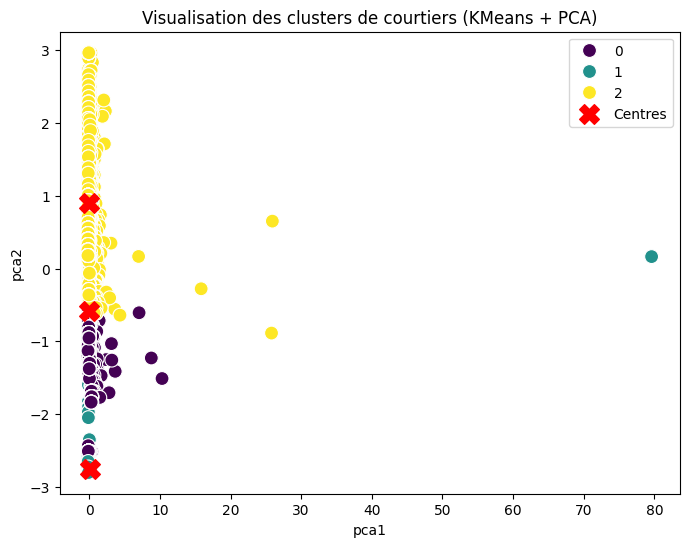

In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Encoder la variable catégorielle
df_cluster = df_agg.copy()
df_cluster = pd.get_dummies(df_cluster, columns=["courtier_segmentation_interne"], drop_first=True)

# Sélection des colonnes pour clustering
features = ["nbre_client", "courtier_anciennete_annees"] + \
           [col for col in df_cluster.columns if "courtier_segmentation_interne_" in col]

X = df_cluster[features]

# Standardiser les variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Clusterisation
k = 3  # nombre de clusters souhaité
kmeans = KMeans(n_clusters=k, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

# PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster["pca1"] = X_pca[:,0]
df_cluster["pca2"] = X_pca[:,1]

# Plot des clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cluster, x="pca1", y="pca2", hue="cluster", palette="viridis", s=100)

# Ajouter les centres de clusters projetés sur PCA
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c='red', s=200, marker='X', label='Centres')
plt.title("Visualisation des clusters de courtiers (KMeans + PCA)")
plt.legend()
plt.show()

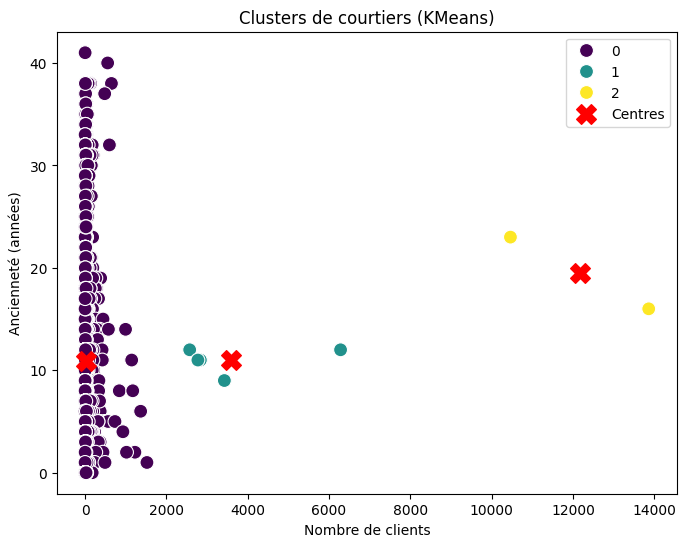

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Colonnes pour le clustering
X = df_agg[["nbre_client", "courtier_anciennete_annees"]]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df_agg["cluster"] = kmeans.fit_predict(X_scaled)

# Visualisation 2D
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_agg, x="nbre_client", y="courtier_anciennete_annees", 
                hue="cluster", palette="viridis", s=100)

# Ajouter les centres des clusters
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, marker='X', label='Centres')

plt.title("Clusters de courtiers (KMeans)")
plt.xlabel("Nombre de clients")
plt.ylabel("Ancienneté (années)")
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(df_cluster["resiliation_cat"], df_cluster["cluster"])
print("NMI:", nmi)

#mauvais tenter d'autre clusterisation sur courtier


NMI: 0.004839903395231585


In [ ]:
df["courtier_code_partenaire"].nunique()

4862

In [ ]:
df_courtier[["courtier_code_partenaire", "resiliation_cat", "target_resiliation_6mois", "courtier_anciennete_annees","courtier_segmentation_interne"]].groupby("courtier_code_partenaire").agg({'resiliation_cat':'sum', 'target_resiliation_6mois':'sum'})

,resiliation_cat,target_resiliation_6mois
courtier_code_partenaire,,
70099,8,0
70141,3,0
70274,9,0
70281,129,6
70288,9,0
...,...,...
556879,1,0
556907,21,2
557166,2,0


On remarque que les 98 courtiers ont un taux de résiliation interne de 100%. Sur ces 98 courtiers, 

Les courtiers code partenaires 115508, 371190 et 402431 constituent à eux seuls 16 % des résiliations. Zoomons sur les codes apporteurs associés à ces courtiers pour voir